## Static modification of the volume of an oscillator

In [1]:
from matplotlib import pyplot as plt

from engine import Chain, ModulatedVolume, SawtoothOscillator, SineOscillator, Volume

num_samples = 44100

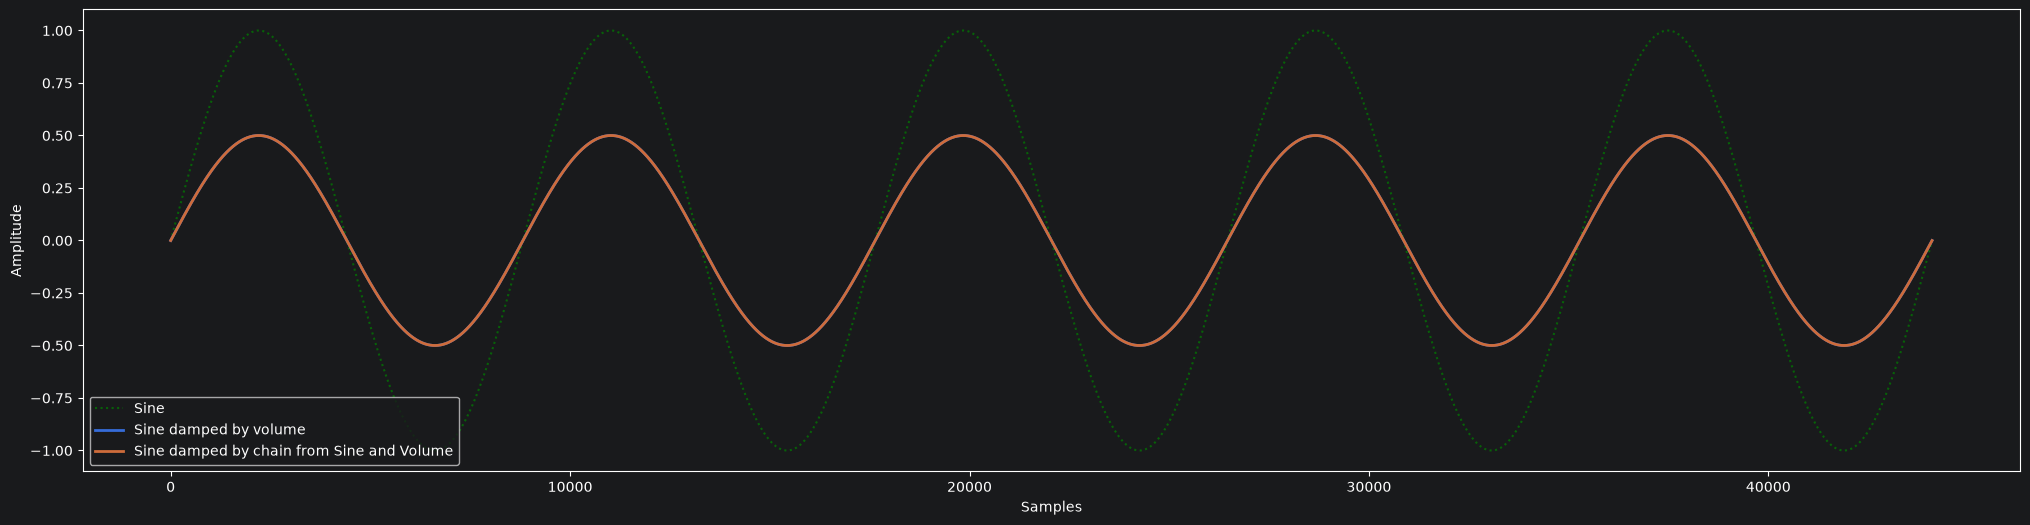

In [2]:
osc = SineOscillator(frequency=5, amplitude=1, phase=0)
samples_sine = osc.get_samples(num_samples)

volume = Volume(amplitude=0.5)  # Reduce volume by 0.2
samples_vol = volume(osc.get_samples(num_samples))

# Alternatively, use a chain (same as above)
chain = Chain(osc, volume)
samples_chain = chain.get_samples(num_samples)

fig, ax = plt.subplots(1, 1, figsize=(25, 6))
plt.plot(samples_sine, linestyle=":", color="g", alpha=0.7, label="Sine")
plt.plot(samples_vol, label="Sine damped by volume", linewidth=2)
plt.plot(samples_chain, label="Sine damped by chain from Sine and Volume", linewidth=2)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.legend()
plt.show()

## Sine Oscillator with Modulated Volume

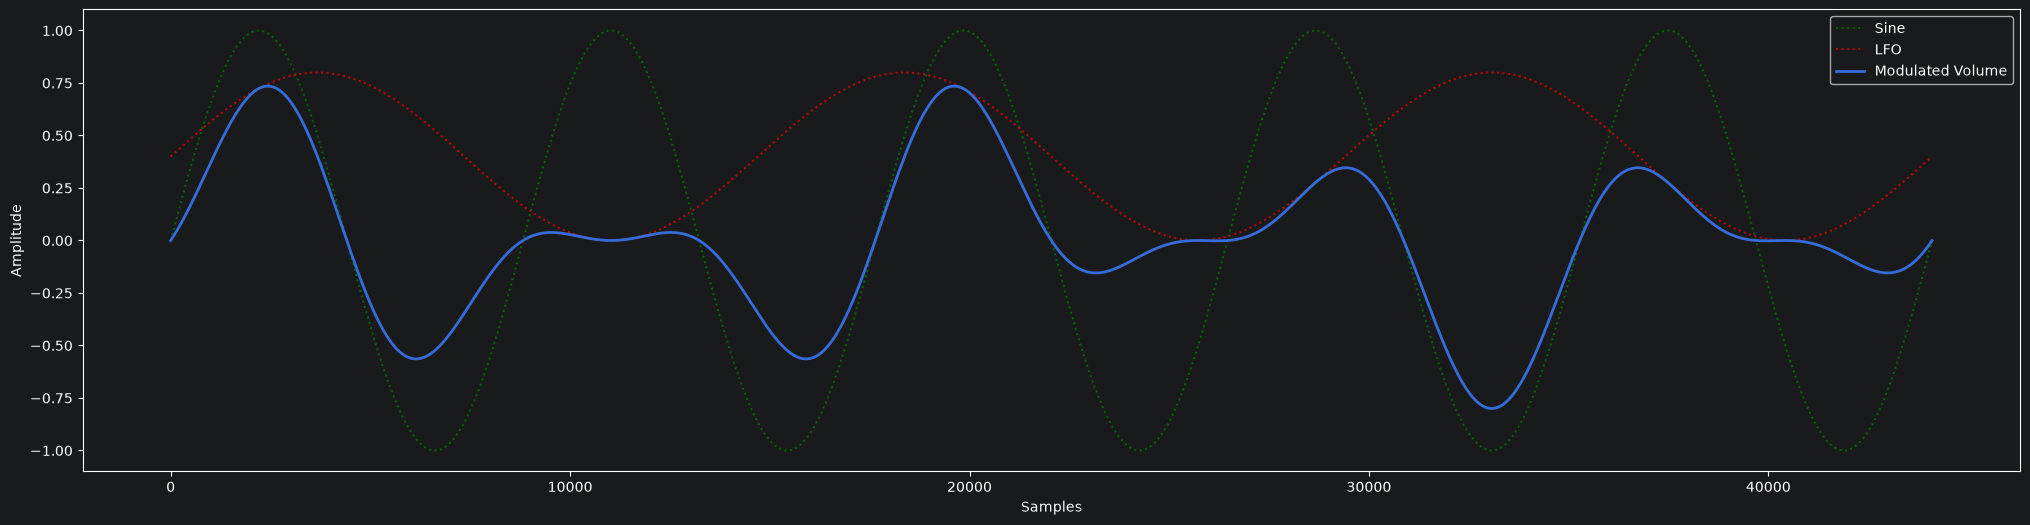

In [3]:
osc = SineOscillator(frequency=5, amplitude=1, phase=0)
samples_sine = osc.get_samples(num_samples)

lfo = SineOscillator(frequency=3, amplitude=0.8, phase=0, wave_range=(0, 1))
samples_lfo = lfo.get_samples(num_samples)

mod_vol = ModulatedVolume(lfo)
samples_mod = mod_vol(samples_sine)

fig, ax = plt.subplots(1, 1, figsize=(25, 6))
plt.plot(samples_sine, linestyle=":", color="g", alpha=0.7, label="Sine")
plt.plot(samples_lfo, linestyle=":", color="r", alpha=0.7, label="LFO")
plt.plot(samples_mod, label="Modulated Volume", linewidth=2)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.legend()
plt.show()

## Sawtooth Oscillator with Modulated Volume

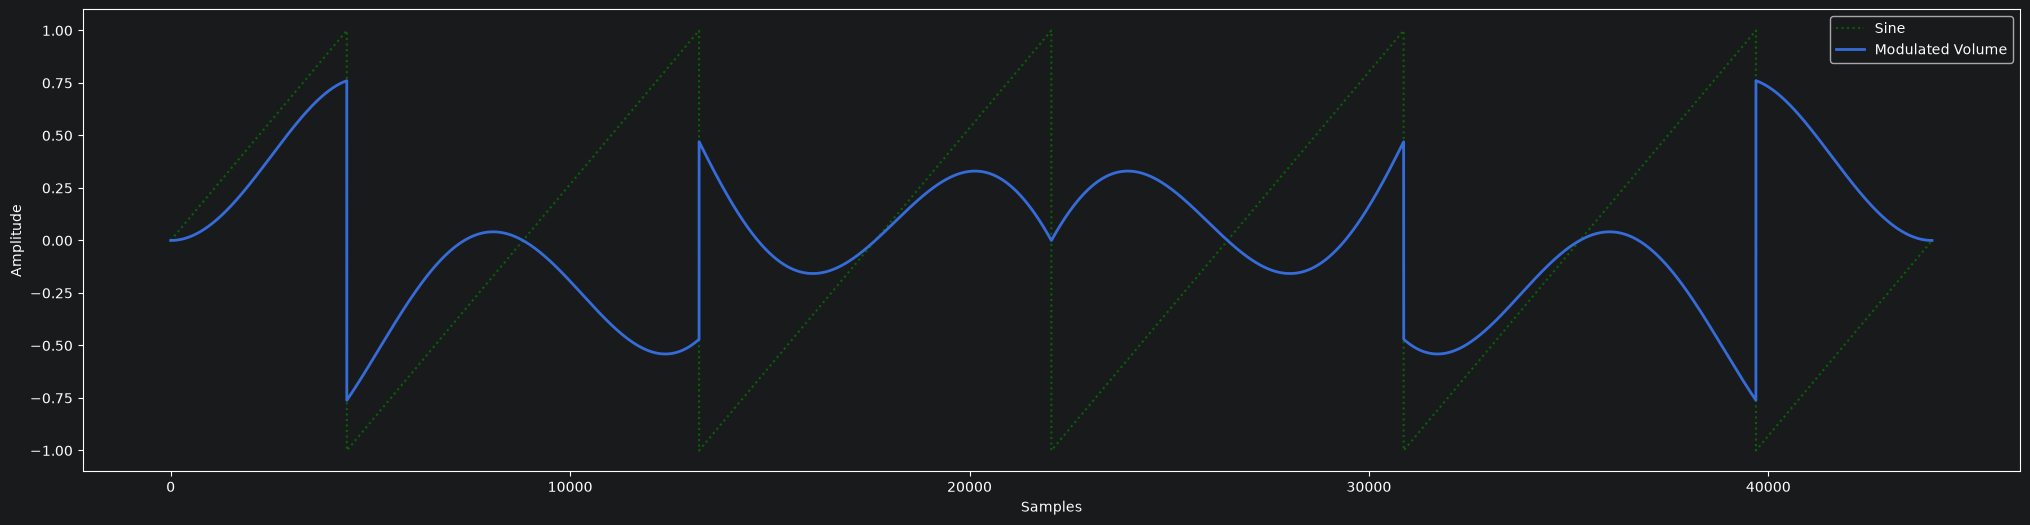

In [4]:
osc = SawtoothOscillator(frequency=5, amplitude=1, phase=0)
samples_sine = osc.get_samples(num_samples)

mod_vol = ModulatedVolume(SineOscillator(frequency=3, amplitude=0.8, phase=0))
samples_mod = mod_vol(samples_sine)

fig, ax = plt.subplots(1, 1, figsize=(25, 6))
plt.plot(samples_sine, linestyle=":", color="g", alpha=0.7, label="Sine")
plt.plot(samples_mod, label="Modulated Volume", linewidth=2)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.legend()
plt.show()